# D3 — Technology Migration Graph

Reads edge and node Parquet files from GCS and visualises:
- Top migration flows (bar chart)
- Net flow (sink vs source technologies)
- Sankey diagram (Plotly)
- Force-directed network graph (networkx + matplotlib)
- PageRank & betweenness centrality rankings

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid')
print('Environment ready.')

Environment ready.


## 1. Load data

In [2]:
edges = pd.read_parquet(f'gs://{BUCKET}/processed/d3_edges/')
nodes = pd.read_parquet(f'gs://{BUCKET}/processed/d3_nodes/')

print(f'Edges: {len(edges)} rows')
print(f'Nodes: {len(nodes)} rows')
print('\nEdge columns:', edges.columns.tolist())
print('Node columns:', nodes.columns.tolist())
edges.head(5)

Edges: 11 rows
Nodes: 16 rows

Edge columns: ['from_tech', 'to_tech', 'migration_count', 'years_active', 'first_year', 'last_year']
Node columns: ['tech', 'out_weight', 'in_weight', 'net_flow', 'pagerank', 'betweenness']


,from_tech,to_tech,migration_count,years_active,first_year,last_year
0,yarn,npm,27,4,2017,2021
1,mocha,jest,24,1,2016,2016
2,travis,circleci,24,2,2015,2019
3,npm,yarn,18,2,2017,2018
4,mysql,postgres,10,1,2015,2015


## 2. Top migration flows

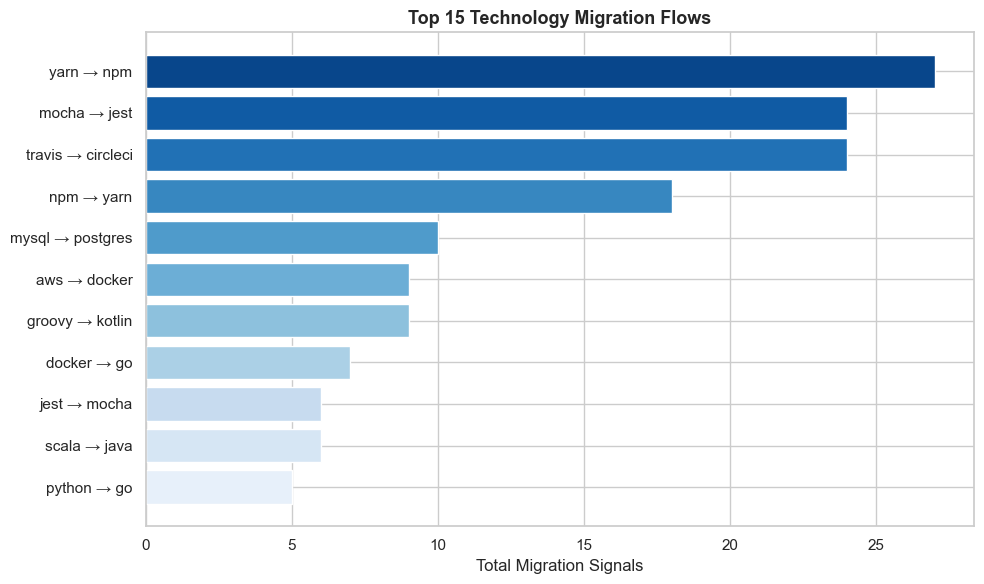

In [3]:
top_edges = edges.nlargest(15, 'migration_count').copy()
top_edges['pair'] = top_edges['from_tech'] + ' → ' + top_edges['to_tech']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_edges['pair'], top_edges['migration_count'],
               color=sns.color_palette('Blues_r', len(top_edges)))
ax.set_xlabel('Total Migration Signals')
ax.set_title('Top 15 Technology Migration Flows', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/d3_top_flows.png', dpi=150)
plt.show()

## 3. Net flow — technology sinks vs sources

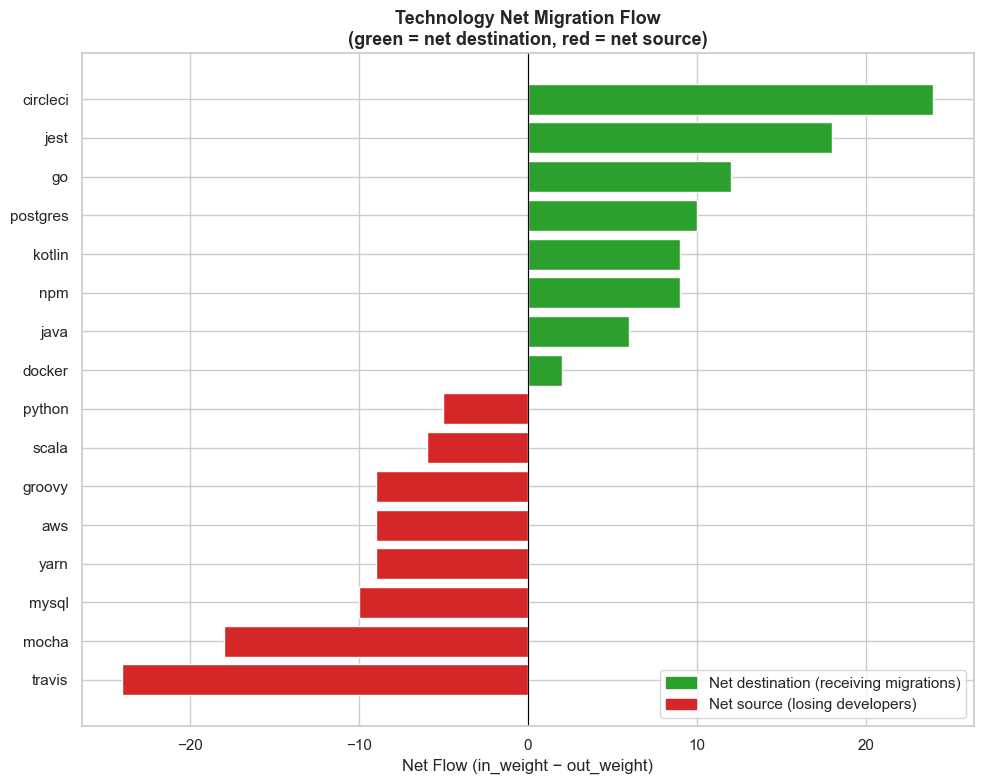

In [4]:
nodes_sorted = nodes.sort_values('net_flow', ascending=True)
colors = ['#d62728' if v < 0 else '#2ca02c' for v in nodes_sorted['net_flow']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(nodes_sorted['tech'], nodes_sorted['net_flow'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Net Flow (in_weight − out_weight)')
ax.set_title('Technology Net Migration Flow\n(green = net destination, red = net source)',
             fontsize=13, fontweight='bold')

green_patch = mpatches.Patch(color='#2ca02c', label='Net destination (receiving migrations)')
red_patch   = mpatches.Patch(color='#d62728', label='Net source (losing developers)')
ax.legend(handles=[green_patch, red_patch], loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/d3_net_flow.png', dpi=150)
plt.show()

## 4. Sankey diagram of migration flows

In [5]:
# Use top-20 edges for clarity
sankey_edges = edges.nlargest(20, 'migration_count')

all_techs = list(set(sankey_edges['from_tech'].tolist() + sankey_edges['to_tech'].tolist()))
tech_idx  = {t: i for i, t in enumerate(all_techs)}

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15, thickness=20,
        label=all_techs,
        color='rgba(31, 119, 180, 0.8)',
    ),
    link=dict(
        source=[tech_idx[t] for t in sankey_edges['from_tech']],
        target=[tech_idx[t] for t in sankey_edges['to_tech']],
        value=sankey_edges['migration_count'].tolist(),
    ),
))
fig.update_layout(
    title_text='Technology Migration Flows (Sankey)',
    font_size=12,
    width=950, height=550,
)
fig.write_html('../outputs/d3_sankey.html')
fig.show()

## 5. Force-directed network graph

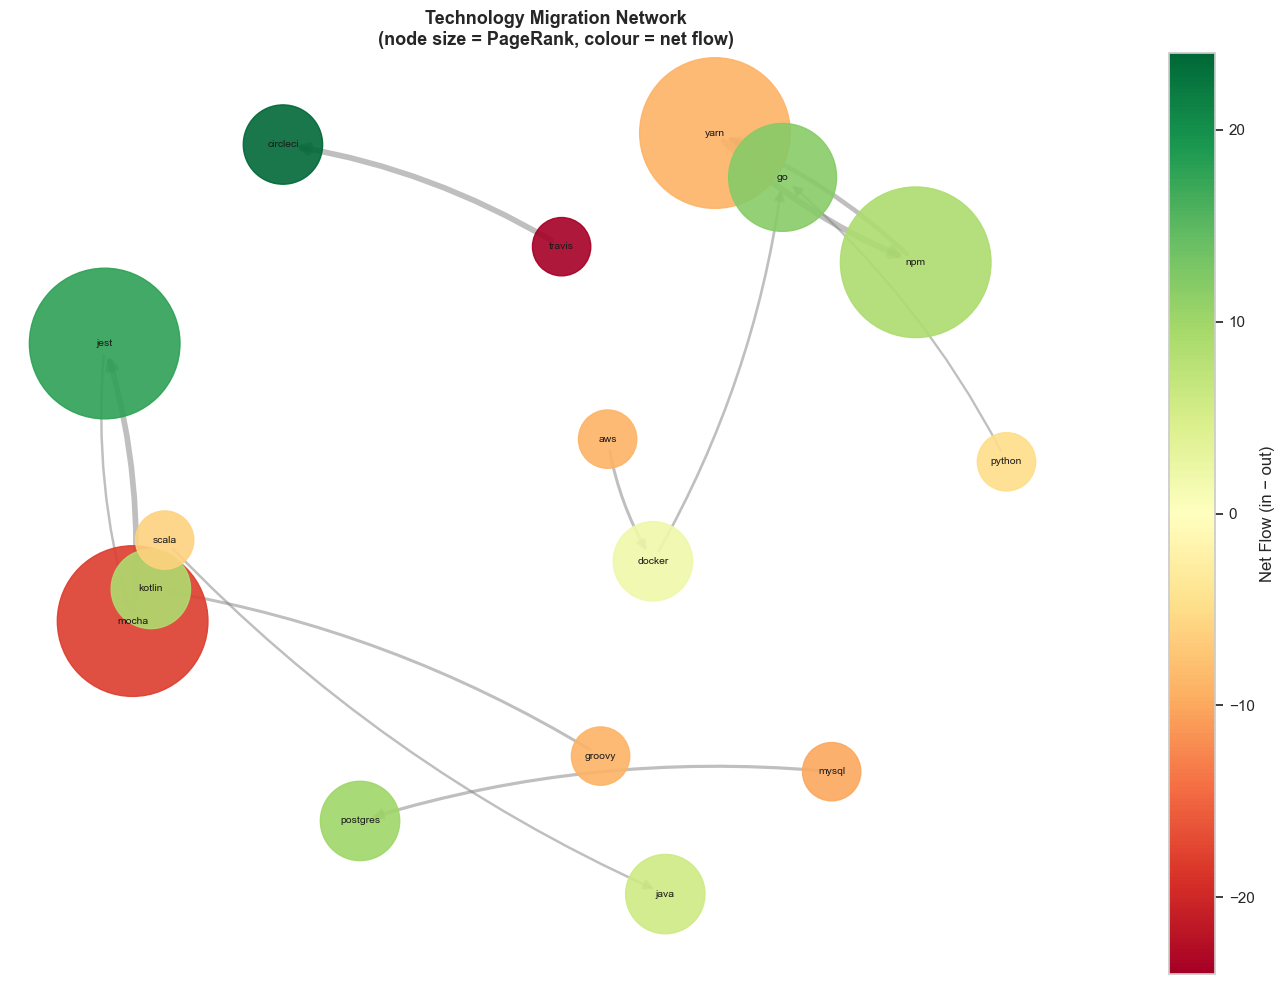

In [6]:
G = nx.DiGraph()
for _, row in edges.iterrows():
    G.add_edge(row['from_tech'], row['to_tech'], weight=row['migration_count'])

# Node size ∝ pagerank, colour ∝ net_flow
node_pr  = nodes.set_index('tech')['pagerank'].to_dict()
node_nf  = nodes.set_index('tech')['net_flow'].to_dict()

node_sizes = [max(300, node_pr.get(n, 0) * 80000) for n in G.nodes]
min_nf, max_nf = min(node_nf.values()), max(node_nf.values())
norm_nf = [(node_nf.get(n, 0) - min_nf) / (max_nf - min_nf + 1e-9) for n in G.nodes]
node_colors = [plt.cm.RdYlGn(v) for v in norm_nf]

edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_w = max(edge_weights)
edge_widths = [1.0 + 3.5 * (w / max_w) for w in edge_weights]

pos = nx.spring_layout(G, k=2.5, seed=42, weight='weight')

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7.5, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths,
                       alpha=0.5, edge_color='grey',
                       arrows=True, arrowsize=15,
                       connectionstyle='arc3,rad=0.1', ax=ax)

sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                            norm=plt.Normalize(vmin=min_nf, vmax=max_nf))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Net Flow (in − out)')
ax.set_title('Technology Migration Network\n'
             '(node size = PageRank, colour = net flow)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/d3_network.png', dpi=150)
plt.show()

## 6. PageRank & Betweenness centrality rankings

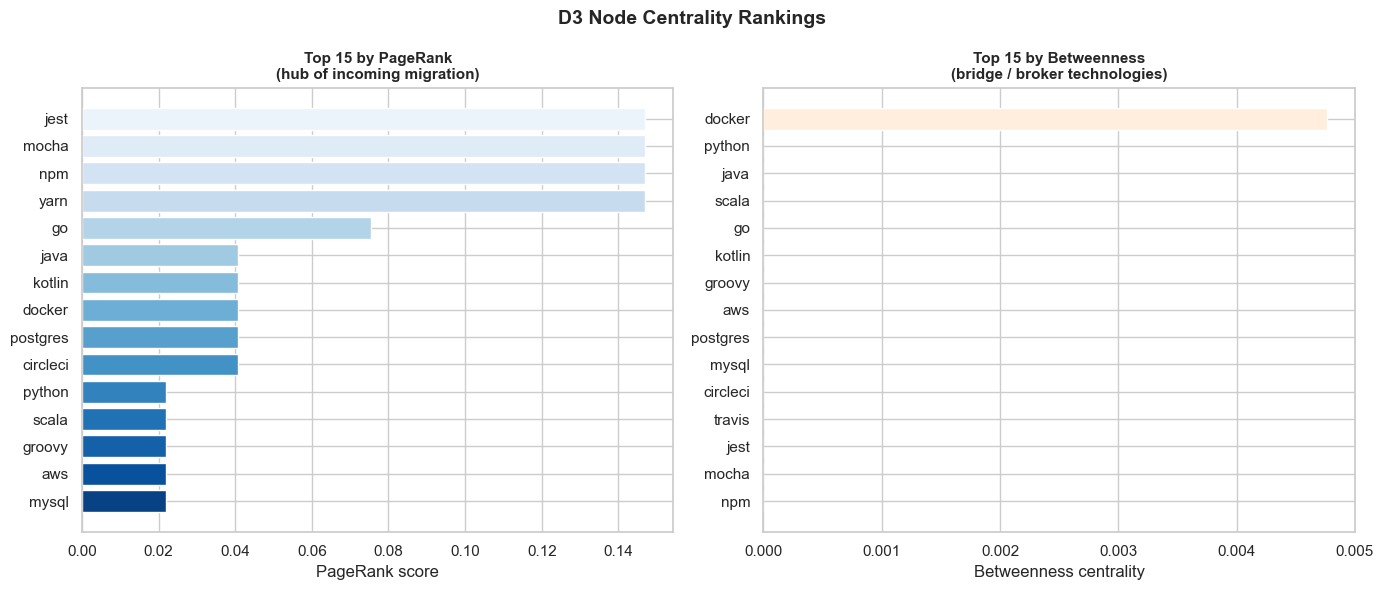

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

pr_sorted = nodes.sort_values('pagerank', ascending=True).tail(15)
ax1.barh(pr_sorted['tech'], pr_sorted['pagerank'],
         color=sns.color_palette('Blues_r', len(pr_sorted)))
ax1.set_title('Top 15 by PageRank\n(hub of incoming migration)', fontsize=11, fontweight='bold')
ax1.set_xlabel('PageRank score')

bt_sorted = nodes.sort_values('betweenness', ascending=True).tail(15)
ax2.barh(bt_sorted['tech'], bt_sorted['betweenness'],
         color=sns.color_palette('Oranges_r', len(bt_sorted)))
ax2.set_title('Top 15 by Betweenness\n(bridge / broker technologies)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Betweenness centrality')

plt.suptitle('D3 Node Centrality Rankings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d3_centrality.png', dpi=150)
plt.show()